In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scip
import sklearn as sk
from sklearn.neighbors import KernelDensity

PLANNING A TELESCOPE OBSERVATION

In [18]:
#Markov Chain

def markov_chain(p_clear_cloudy, p_clear_clear, initial_weather, n_days):

    weather = [initial_weather]
    current_weather = initial_weather
    
    for _ in range(n_days):
        if current_weather == 0:  # Clear is represented by 0
            next_weather = np.random.choice([0, 1], p=[p_clear_clear, 1-p_clear_clear])
        else:  # Cloudy is represented by 1
            next_weather = np.random.choice([0, 1], p=[p_clear_cloudy, 1-p_clear_cloudy])
        weather.append(next_weather)
        current_weather = next_weather
        
    return weather


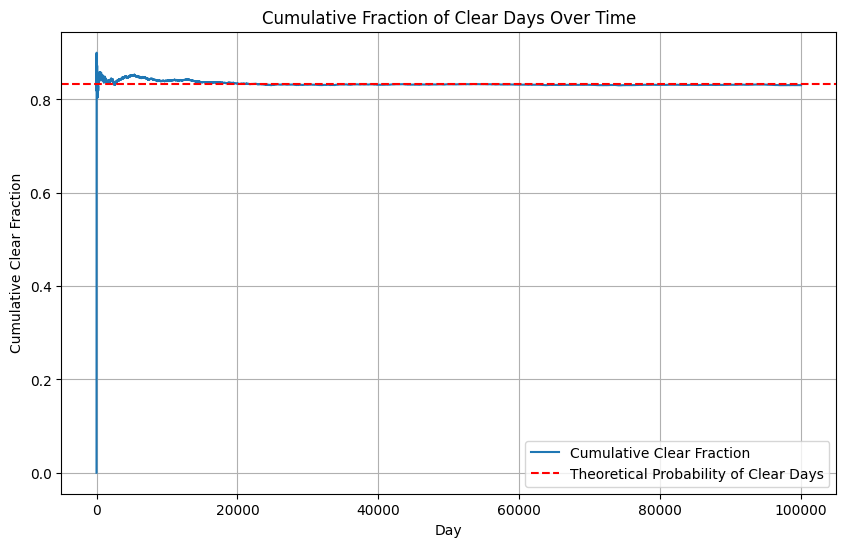

Theoretical probability of clear day: 0.8333333333333334
MC probability of a clear day: 0.8332055454336074


In [19]:
p_clear_cloudy = 0.5 # Probability of clear day following a cloudy day
p_clear_clear = 0.9 # Probability of clear day following a clear day

#p_clear is the overall probability of clear days and can be calculated from the transition probabilities using the formula:
#p_clear = p_clear_cloudy / (p_clear_cloudy + (1 - p_clear_clear)) 
p_clear = p_clear_cloudy / (p_clear_cloudy + (1 - p_clear_clear))

p_cloudy = 1 - p_clear # Overall probability of cloudy days


initial_weather = 1  # Start with cloudy weather
n_days = np.int_(1e5)
weather_sequence = markov_chain(p_clear_cloudy, p_clear_clear, initial_weather, n_days)

#np.cumsum selects only the clear days (0s) and counts them cumulatively
#np.arange creates an array of day numbers starting from 1 to n_days + 1 (since we have n_days transitions, we have n_days + 1 total days including the initial day).
cumulative_clear_fraction = np.cumsum(np.array(weather_sequence) == 0) / np.arange(1, n_days + 2)

# Plot of the cumulative fracion of clear days over the total number of days to see if it converges to the theoretical probability of clear days (p_clear).
plt.figure(figsize=(10, 6))
plt.plot(cumulative_clear_fraction, label='Cumulative Clear Fraction')
plt.axhline(p_clear, color='red', linestyle='--', label='Theoretical Probability of Clear Days')
plt.xlabel('Day')
plt.ylabel('Cumulative Clear Fraction')
plt.title('Cumulative Fraction of Clear Days Over Time')
plt.legend()
plt.grid()
plt.show()
print( f"Theoretical probability of clear day: {p_clear}")
print ( f"MC probability of a clear day: {np.mean(cumulative_clear_fraction[2000:])}")




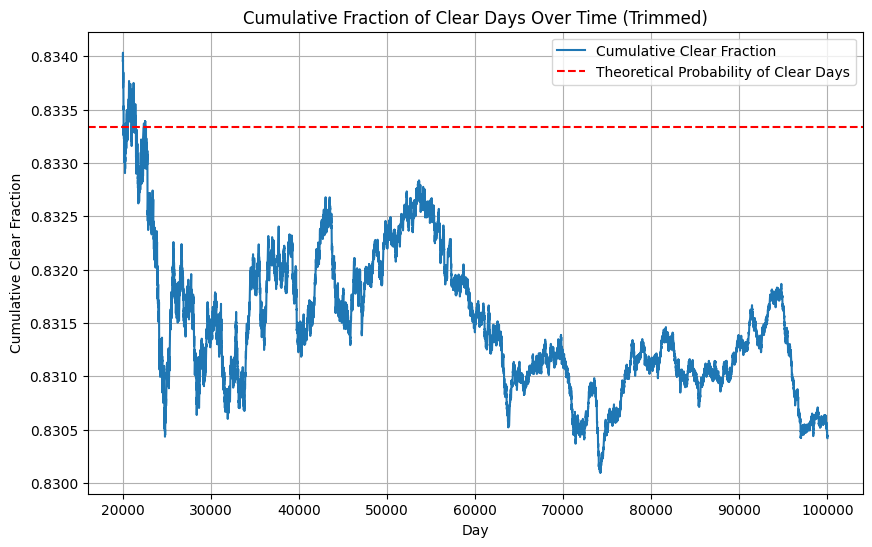

In [20]:
#Cut off the first burn_in days (the "burn-in" period) to see if the cumulative clear fraction converges to the theoretical probability of clear days (p_clear).
burn_in = 20000
cumulative_clear_fraction_trimmed = cumulative_clear_fraction[burn_in:]
days_trimmed = np.arange(burn_in, n_days + 1)  # index range for trimmed data

plt.figure(figsize=(10, 6))
plt.plot(days_trimmed, cumulative_clear_fraction_trimmed, label='Cumulative Clear Fraction')
plt.axhline(p_clear, color='red', linestyle='--', label='Theoretical Probability of Clear Days')
plt.xlabel('Day')
plt.ylabel('Cumulative Clear Fraction')
plt.title('Cumulative Fraction of Clear Days Over Time (Trimmed)')
plt.legend()
plt.grid()
plt.show()

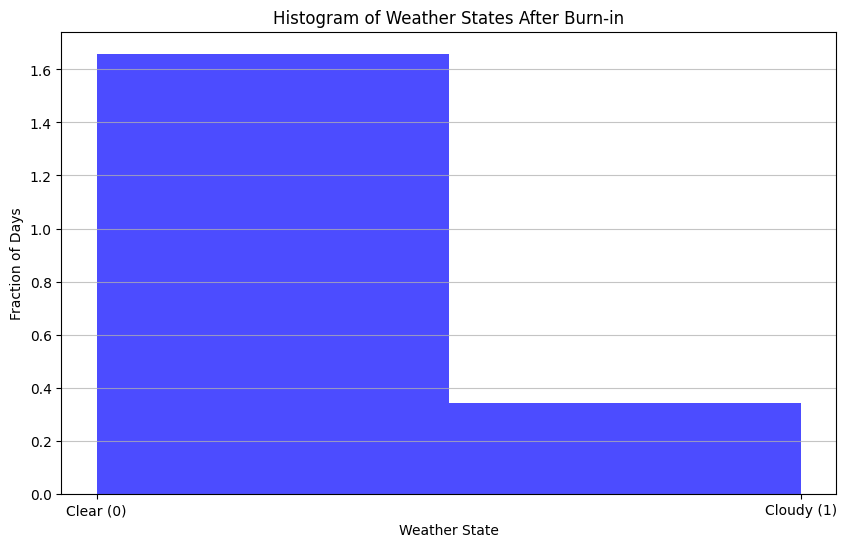

Most likely p(clear): 0.8295
Uncertainty (Standard Error): 0.001329


In [21]:
# Create a histogram of the weather_sequence AFTER burn-in
plt.figure(figsize=(10, 6))
plt.hist(weather_sequence[burn_in:], bins=2, density=True, alpha=0.7, color='blue')
plt.xticks([0, 1], ['Clear (0)', 'Cloudy (1)'])
plt.xlabel('Weather State')
plt.ylabel('Fraction of Days')
plt.title('Histogram of Weather States After Burn-in')
plt.grid(axis='y', alpha=0.75)
plt.show() 

# Since the state is discrete (0 or 1), a histogram of the states just gives you two bars. The fraction of 0s is your estimate.

final_samples = weather_sequence[burn_in:]
estimated_p_clear = np.mean(np.array(final_samples) == 0) # Fraction of clear days in the final samples
error_estimate = np.std(np.array(final_samples) == 0) / np.sqrt(len(final_samples)) # Standard error of the mean

print(f"Most likely p(clear): {estimated_p_clear:.4f}")
print(f"Uncertainty (Standard Error): {error_estimate:.6f}")


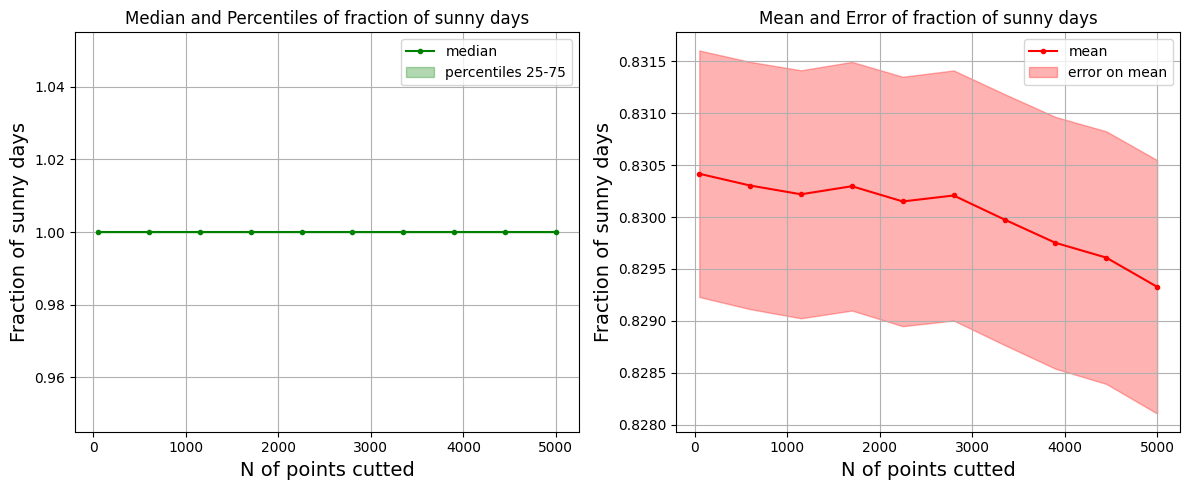

In [33]:
# See how the number of burn in points influences the value of the statistics

n_clear = (np.array(weather_sequence) == 0).astype(int)

# number of burn in points
cuts = np.linspace(50, 5000, 10)
median = []
mean = []
perc_25 = []
perc_75 = []
s_mean = []

for c in cuts:
    cut_n_sun = np.copy(n_clear[int(c):])  
    median.append(np.median(cut_n_sun))
    mean.append(np.mean(cut_n_sun))
    perc_25.append(np.percentile(cut_n_sun, 25))
    perc_75.append(np.percentile(cut_n_sun, 75))
    s_mean.append(np.std(cut_n_sun)/np.sqrt(len(cut_n_sun)))

s_down = np.array(mean)-np.array(s_mean)
s_up = np.array(mean)+np.array(s_mean)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(cuts, median, marker='.', label='median', color='green')
axs[0].fill_between(cuts, perc_25, perc_75, label='percentiles 25-75', color='green', alpha=0.3)
axs[0].set_title('Median and Percentiles of fraction of sunny days')
axs[0].set_xlabel('N of points cutted', fontsize=14)
axs[0].set_ylabel('Fraction of sunny days', fontsize=14)
axs[0].legend()
axs[0].grid()
axs[1].plot(cuts, mean, marker='.', label='mean', color='red')
axs[1].fill_between(cuts, s_down, s_up, label='error on mean', color='red', alpha=0.3)

axs[1].set_title('Mean and Error of fraction of sunny days')
axs[1].set_xlabel('N of points cutted', fontsize=14)
axs[1].set_ylabel('Fraction of sunny days', fontsize=14)
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

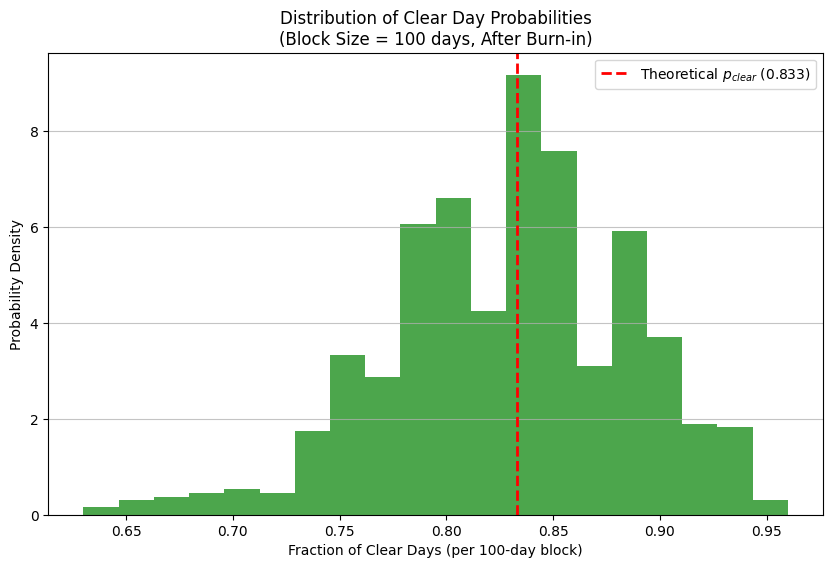

In [23]:
# Plot a histo for the distribution of clear day over constant block of 100 days
block_size = 100

final_sequence = np.array(weather_sequence[burn_in:])
n_blocks = len(final_sequence) // block_size
blocked_data = final_sequence[:n_blocks * block_size].reshape((n_blocks, block_size))

clear_fractions_per_block = np.mean(blocked_data == 0, axis=1)

plt.figure(figsize=(10, 6))

plt.hist(clear_fractions_per_block, bins='fd', density=True, alpha=0.7, color='green')

plt.axvline(p_clear, color='red', linestyle='--', linewidth=2, label=f'Theoretical $p_{{clear}}$ ({p_clear:.3f})')

plt.xlabel(f'Fraction of Clear Days (per {block_size}-day block)')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Clear Day Probabilities\n(Block Size = {block_size} days, After Burn-in)')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()